In [2]:
import scanpy as sc 
import os

In [3]:
os.chdir('/Users/iriskwon/Desktop/mouse-cereb-dev/mouse-cereb-dev/')
os.getcwd()

'/Users/iriskwon/Desktop/mouse-cereb-dev/mouse-cereb-dev'

In [ ]:
# Command to run Vitessce on RDS file for cellxgene: 
#python -m vitessce launch public/data/cb_dev_annotated_v3.h5ad --static ./vitessce_web

Steps: 
>conda create -n vitessce1 python=3.9
>
>conda activate vitessce1
>
>pip install "vitessce[all]==1.0.11"



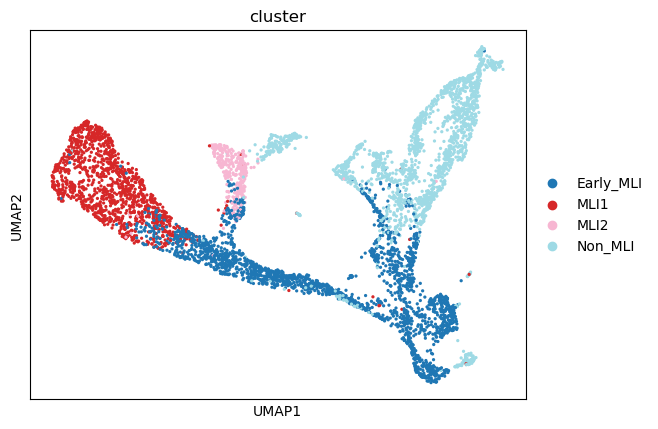

In [4]:
from vitessce import VitessceConfig, ViewType as vt, CoordinationType as ct, AnnDataWrapper
import scanpy as sc

# Load your h5ad
adata_path = "public/data/cb_dev_annotated_v3.h5ad"
adata = sc.read_h5ad(adata_path)

sc.pl.umap(adata, color="cluster", palette="tab20")

In [15]:
# Optionally, save as zarr for Vitessce 3.x
zarr_path = "public/data/cb_dev_annotated_v3.zarr"
adata.write_zarr(zarr_path)

In [16]:
import zarr
z = zarr.open("public/data/cb_dev_annotated_v3.zarr", mode='r')
print(z.tree())

/
 ├── X (5519, 2000) float64
 ├── layers
 ├── obs
 │   ├── Age
 │   │   ├── categories (6,) object
 │   │   └── codes (5519,) int8
 │   ├── Pseudotime (5519,) float64
 │   ├── _index (5519,) object
 │   ├── cluster
 │   │   ├── categories (4,) object
 │   │   └── codes (5519,) int8
 │   ├── donor_id
 │   │   ├── categories (8,) object
 │   │   └── codes (5519,) int8
 │   ├── nCount_RNA (5519,) float64
 │   ├── nFeature_RNA (5519,) int32
 │   └── sex
 │       ├── categories (2,) object
 │       └── codes (5519,) int8
 ├── obsm
 │   ├── X_pca (5519, 50) float64
 │   └── X_umap (5519, 2) float64
 ├── obsp
 ├── raw
 │   ├── X
 │   │   ├── data (15602659,) float64
 │   │   ├── indices (15602659,) int32
 │   │   └── indptr (5520,) int32
 │   ├── var
 │   │   ├── _index (22110,) object
 │   │   ├── vst.mean (22110,) float64
 │   │   ├── vst.variable (22110,) int32
 │   │   ├── vst.variance (22110,) float64
 │   │   ├── vst.variance.expected (22110,) float64
 │   │   └── vst.variance.standard

In [5]:
from vitessce import VitessceConfig, ViewType as vt, CoordinationType as ct, AnnDataWrapper
import scanpy as sc
# Create Vitessce config
vc = VitessceConfig(schema_version="1.0.15", name="Mouse Cerebellum Development")
zarr_path = "public/data/cb_dev_annotated_v3.zarr"

dataset = vc.add_dataset("CB Dev").add_object(AnnDataWrapper(
    adata_path = zarr_path,
    obs_feature_matrix_path="X",
    obs_embedding_paths=["obsm/X_umap"],
    obs_embedding_names = ["UMAP"],   
    obs_set_paths=["obs/cluster", "obs/donor_id", "obs/sex"],  # categorical
    obs_set_names=["Cluster", "Donor ID", "Sex"],
    obs_continuous_paths=["obs/Pseudotime"],                    # continuous
    obs_continuous_names=["Pseudotime"]
))

# === Add views ===
desc = vc.add_view(vt.DESCRIPTION, dataset=dataset).set_props(description="Developing Mouse Cerebellum Coronal Slice")
scatter = vc.add_view(vt.SCATTERPLOT, dataset=dataset, mapping="UMAP")  # can use UMAP as spatial
cell_sets = vc.add_view(vt.OBS_SETS, dataset=dataset)
genes = vc.add_view(vt.FEATURE_LIST, dataset=dataset)
#heatmap = vc.add_view(vt.HEATMAP, dataset=dataset)

# Layout
vc.layout(desc / ((cell_sets / genes) | scatter));

# Render the widget in Jupyter
vc.widget()


VitessceWidget(config={'version': '1.0.15', 'name': 'Mouse Cerebellum Development', 'description': '', 'datase…

In [19]:
adata.obsm.keys()

KeysView(AxisArrays with keys: X_pca, X_umap)

In [7]:
path = "/Users/iriskwon/Desktop/mouse-cereb-dev/"
os.chdir(path)
# verify the change
print("New working directory:", os.getcwd())

New working directory: /Users/iriskwon/Desktop/mouse-cereb-dev


In [8]:
# Export your config to a Python dictionary
config_dict = vc.to_dict(base_url="configs_for_vitessce")

import json 

# Write it to a JS file for your React app
with open("configs_for_vitessce/cb_dev-config.js", "w") as f:
    f.write("export const cbDevConfig = ")
    json.dump(config_dict, f, indent=2)
    f.write(";")
